In [4]:
import pandas as pd
from collections import Counter
import re

def analyze_keyword_frequencies(file_path, min_count=10):
    # 1. 데이터 로드
    df = pd.read_csv(file_path)
    
    # ---------------------------------------------------------
    # [중복 제거] 논문 ID 기준으로 중복 행 제거
    df_unique = df.drop_duplicates(subset=['논문ID']).copy()
    print(f"✅ 중복 제거 완료: {len(df)}개 행 -> {len(df_unique)}개 논문으로 압축됨")
    # ---------------------------------------------------------
    
    # 2. 키워드 분리 및 정제
    all_keywords = []
    for k_str in df_unique['키워드'].dropna():
        # 구분자( , 또는 ; ) 처리 및 공백 제거, 소문자화
        words = [w.strip().lower() for w in str(k_str).replace(';', ',').split(',') if w.strip()]
        all_keywords.extend(words)

    # 3. 빈도 계산
    counts = Counter(all_keywords)
    
    # 4. 전체 데이터를 데이터프레임으로 변환
    # most_common()에 인자를 주지 않으면 전체 키워드를 가져옵니다.
    full_freq_df = pd.DataFrame(counts.most_common(), columns=['Keyword', 'Count'])
    
    # ---------------------------------------------------------
    # [핵심 수정] 10회 이상 등장한 키워드만 필터링
    freq_df = full_freq_df[full_freq_df['Count'] >= min_count].copy()
    # ---------------------------------------------------------
    
    # 5. 언어 판별 함수 적용
    def get_lang_type(text):
        if re.search('[가-힣]', str(text)):
            return '한글/혼용'
        return '영문'

    freq_df['Type'] = freq_df['Keyword'].apply(get_lang_type)
    
    # 6. 결과 출력 및 저장
    print(f"\n📊 {min_count}회 이상 등장한 키워드 분석 현황")
    print("-" * 60)
    if not freq_df.empty:
        print(freq_df)
        # 파일로 저장 (분석용)
        output_name = f'키워드_빈도_분석_{min_count}회이상.csv'
        freq_df.to_csv(output_name, index=False, encoding='utf-8-sig')
        print("-" * 60)
        print(f"✅ 필터링된 키워드 총 {len(freq_df)}개가 '{output_name}'에 저장되었습니다.")
    else:
        print(f"❌ {min_count}회 이상 등장한 키워드가 없습니다.")
    
    return freq_df

if __name__ == "__main__":
    file_name = 'KCI_AI_논문_상세_및_인용데이터.csv'
    # 10회 이상 등장하는 키워드만 분석
    freq_result = analyze_keyword_frequencies(file_name, min_count=10)

✅ 중복 제거 완료: 31264개 행 -> 1072개 논문으로 압축됨

📊 10회 이상 등장한 키워드 분석 현황
------------------------------------------------------------
                     Keyword  Count   Type
0                       인공지능    637  한글/혼용
1    artificial intelligence    487     영문
2                         ai    139     영문
3              generative ai     79     영문
4                       알고리즘     63  한글/혼용
..                       ...    ...    ...
122                invention     10     영문
123                       발명     10  한글/혼용
124                      발명자     10  한글/혼용
125       transformative use     10     영문
126                   변형적 이용     10  한글/혼용

[127 rows x 3 columns]
------------------------------------------------------------
✅ 필터링된 키워드 총 127개가 '키워드_빈도_분석_10회이상.csv'에 저장되었습니다.


In [13]:
import pandas as pd
from collections import Counter
import re
import os

def analyze_keywords_with_mapping(data_file, mapping_file, top_n=50):
    if not os.path.exists(mapping_file):
        print(f"❌ 매핑 파일을 찾을 수 없습니다: {mapping_file}")
        return
    
    # 1. 매핑 사전 생성
    # 매핑 파일의 컬럼명은 'Keyword', 'Target'이라고 가정합니다.
    df_map = pd.read_csv(mapping_file)
    df_map = df_map.dropna(subset=['Keyword', 'Target'])
    
    mapping_dict = dict(zip(
        df_map['Keyword'].astype(str).str.lower().str.strip(), 
        df_map['Target'].astype(str).str.strip()
    ))
    
    # 2. 메인 데이터 로드 및 중복 제거
    df = pd.read_csv(data_file)
    
    # [수정] '논문ID' 컬럼이 실제 파일에 있는지 확인 후 중복 제거
    id_col = '논문ID' if '논문ID' in df.columns else df.columns[0] 
    df_unique = df.drop_duplicates(subset=[id_col]).copy()
    
    # [핵심 수정] 'keywords' 대신 '키워드' 사용
    target_col = '키워드' 
    if target_col not in df.columns:
        # 혹시 '키워드'도 없다면 유사한 이름 찾기
        found_cols = [c for c in df.columns if '키워드' in c or 'keyword' in c.lower()]
        if found_cols:
            target_col = found_cols[0]
        else:
            print(f"❌ '{target_col}' 컬럼을 찾을 수 없습니다. 현재 컬럼: {df.columns.tolist()}")
            return

    print(f"✅ 데이터 로드 완료: {len(df_unique)}개 논문 분석 (사용 컬럼: {target_col})")

    # 3. 키워드 치환 및 수집
    final_keywords = []
    for k_str in df_unique[target_col].dropna():
        # 구분자(;, ,) 처리 및 소문자 정제
        raw_words = [w.strip().lower() for w in str(k_str).replace(';', ',').split(',') if w.strip()]
        
        for word in raw_words:
            # 매핑 사전에 있으면 Target으로 변환, 없으면 원본 유지
            mapped_word = mapping_dict.get(word, word)
            final_keywords.append(mapped_word)

    # 4. 빈도 계산
    counts = Counter(final_keywords)
    all_counts = counts.most_common() 
    
    # 5. 데이터프레임 변환
    freq_df = pd.DataFrame(all_counts, columns=['Keyword', 'Count'])
    
    def get_lang_type(text):
        if re.search('[가-힣]', str(text)):
            return '한글/혼용'
        return '영문'
    freq_df['Type'] = freq_df['Keyword'].apply(get_lang_type)

    # 6. 출력
    print(f"\n📊 매핑 적용 후 상위 {top_n}개 키워드")
    print("-" * 60)
    print(freq_df.head(20)) 
    print("-" * 60)
    
    return freq_df

if __name__ == "__main__":
    DATA_FILE = 'KCI_AI_논문_상세_및_인용데이터.csv'
    MAPPING_FILE = '키워드 변환 표.csv'
    
    result = analyze_keywords_with_mapping(DATA_FILE, MAPPING_FILE)
    
    if result is not None:
        result.to_csv('매핑후_키워드_빈도.csv', index=False, encoding='utf-8-sig')
        print(f"💾 결과가 '매핑후_키워드_빈도.csv'로 저장되었습니다.")

✅ 데이터 로드 완료: 1072개 논문 분석 (사용 컬럼: 키워드)

📊 매핑 적용 후 상위 50개 키워드
------------------------------------------------------------
      Keyword  Count   Type
0        인공지능   1420  한글/혼용
1    생성형 인공지능    197  한글/혼용
2        알고리즘    120  한글/혼용
3         저작권    119  한글/혼용
4        공정이용     82  한글/혼용
5         법인격     71  한글/혼용
6        머신러닝     71  한글/혼용
7        개인정보     71  한글/혼용
8         딥러닝     66  한글/혼용
9        빅데이터     66  한글/혼용
10        투명성     60  한글/혼용
11      제조물책임     54  한글/혼용
12    4차 산업혁명     53  한글/혼용
13     개인정보보호     43  한글/혼용
14       거버넌스     42  한글/혼용
15        자율성     41  한글/혼용
16      인공지능법     40  한글/혼용
17         차별     32  한글/혼용
18  eu ai act     32     영문
19       저작권법     32  한글/혼용
------------------------------------------------------------
💾 결과가 '매핑후_키워드_빈도.csv'로 저장되었습니다.


### 키워드 네트워크 분석

In [11]:
import pandas as pd
import networkx as nx
import community.community_louvain as community_louvain
from itertools import combinations
from collections import Counter
import os
import re

def perform_and_save_clusters(data_file, mapping_file, min_edge_weight=2):
    # 1. 설정 및 로드
    EXCLUDE_KEYWORDS = ['인공지능', 'ai', 'artificial intelligence']
    mapping_dict = {}
    if os.path.exists(mapping_file):
        df_map = pd.read_csv(mapping_file).dropna(subset=['Keyword', 'Target'])
        mapping_dict = dict(zip(df_map['Keyword'].astype(str).str.lower(), df_map['Target'].astype(str)))

    df = pd.read_csv(data_file)
    
    # 컬럼명 자동 매칭 (keywords 혹은 키워드가 포함된 컬럼 찾기)
    target_col = None
    for col in df.columns:
        if 'keyword' in col.lower() or '키워드' in col:
            target_col = col
            break
            
    if not target_col:
        raise KeyError(f"파일에서 'keywords' 관련 컬럼을 찾을 수 없습니다. 현재 컬럼: {df.columns.tolist()}")

    df_unique = df.drop_duplicates(subset=['논문ID']).copy()
    
    # 3. 키워드 정제 및 한국어 필터링
    processed_docs = []
    ko_pattern = re.compile('[가-힣]')

    # 수정된 부분: df_unique[target_col] 사용
    for k_str in df_unique[target_col].dropna():
        raw_words = [w.strip().lower() for w in str(k_str).replace(';', ',').split(',') if w.strip()]
        refined_words = []
        for w in raw_words:
            clean_w = re.sub(r'\(.*\)', '', w).strip()
            target_w = mapping_dict.get(w, mapping_dict.get(clean_w, clean_w))
            
            if target_w.lower() not in EXCLUDE_KEYWORDS and ko_pattern.search(target_w):
                refined_words.append(target_w)
        
        refined_words = list(set(refined_words))
        if len(refined_words) >= 2:
            processed_docs.append(refined_words)

    # 4. 네트워크 및 군집화
    G = nx.Graph()
    edge_counts = Counter()
    for words in processed_docs:
        for pair in combinations(sorted(words), 2):
            edge_counts[pair] += 1

    for (node1, node2), weight in edge_counts.items():
        if weight >= min_edge_weight:
            G.add_edge(node1, node2, weight=weight)

    # Louvain 군집화
    partition = community_louvain.best_partition(G, weight='weight', random_state=42)

    # ---------------------------------------------------------
    # 5. [핵심] 결과 데이터프레임 생성 및 저장
    # ---------------------------------------------------------
    cluster_results = []
    for node, cluster_id in partition.items():
        # 각 노드(키워드)의 가중치 기반 연결 정도(Weighted Degree) 계산
        degree = G.degree(node, weight='weight')
        cluster_results.append({
            'Keyword': node,
            'Cluster_ID': cluster_id + 1,  # 1번부터 시작하도록
            'Importance': degree           # 군집 내 중요도 지표
        })

    # 데이터프레임 변환 및 정렬 (군집별, 중요도순)
    result_df = pd.DataFrame(cluster_results)
    result_df = result_df.sort_values(by=['Cluster_ID', 'Importance'], ascending=[True, False])

    # CSV 저장
    output_filename = '키워드_군집_매핑_결과.csv'
    result_df.to_csv(output_filename, index=False, encoding='utf-8-sig')
    
    # 6. 요약 출력
    print(f"✅ 분석 및 저장 완료!")
    print(f"📂 결과 파일: {output_filename}")
    print("-" * 50)
    for cid in sorted(result_df['Cluster_ID'].unique()):
        top_5 = result_df[result_df['Cluster_ID'] == cid].head(5)['Keyword'].tolist()
        print(f"군집 {cid}: {', '.join(top_5)} ...")
    
    return result_df

if __name__ == "__main__":
    df_result = perform_and_save_clusters('KCI_AI_논문_상세_및_인용데이터.csv', '키워드 변환 표.csv')

✅ 분석 및 저장 완료!
📂 결과 파일: 키워드_군집_매핑_결과.csv
--------------------------------------------------
군집 1: 법인격, 제조물책임, 로봇, 자율주행자동차, 위험책임 ...
군집 2: 인공지능의 범죄능력, 인공지능의 형사책임능력 ...
군집 3: 데이터구조, 데이터셋, 물건발명, 인공지능발명 ...
군집 4: 옵트아웃, ai 학습데이터, 메타데이터 ...
군집 5: 딥러닝, 머신러닝, 기계학습, 심층학습, 진보성 ...
군집 6: 인공지능규범, 인공지능백서 ...
군집 7: 투명성, 편향, 차별, 공정성, 편향성 ...
군집 8: 기술주권, 소버린 ai ...
군집 9: 직업교육, 직업능력개발 ...
군집 10: 의사표시의 주체, 전자문서 및 전자거래기본법, 컴퓨터시스템 운영자 ...
군집 11: 인공지능 법, 인공지능법, 인공지능기본법, 인공지능 거버넌스, 인공지능 규제 ...
군집 12: 법률서비스, 변호사법, 사법접근권 ...
군집 13: 강인공지능, 약인공지능 ...
군집 14: 생성형 인공지능, 저작권, 공정이용, 빅데이터, 저작자 ...
군집 15: 조정, 중재, 협상 ...
군집 16: 알고리즘, 규제, 묵시적 담합, 헌법, 동조적 행위 ...
군집 17: 양형, 재범예측 ...
군집 18: 인공지능 저작물, 독창성, 중국 저작권법, 인공지능 저작물의 저작자, 인공지능 저작자 ...
군집 19: 개인정보, 4차 산업혁명, 인공지능 로봇, 사물인터넷, 지능정보사회 ...
군집 20: 법경제학, 자동화 ...
군집 21: ai범죄, 배후정범 ...


### 영문 키워드만 찾기

In [16]:
import pandas as pd
import re
import os

def find_english_only_keyword_papers(file_path):
    # 1. 데이터 로드
    df = pd.read_csv(file_path)
    
    # [체크] 실제 컬럼명 확인 (에러 방지용)
    cols = df.columns.tolist()
    
    # 사용할 컬럼명 설정 (실제 파일 구조에 맞춰 매칭)
    id_col = '논문ID' if '논문ID' in cols else cols[0]
    keyword_col = '키워드' if '키워드' in cols else ('keywords' if 'keywords' in cols else None)
    title_col = '논문제목' if '논문제목' in cols else cols[1] # 제목이 보통 두 번째

    if not keyword_col:
        print(f"❌ 키워드 관련 컬럼을 찾을 수 없습니다. 현재 컬럼: {cols}")
        return None

    # 중복 제거
    df_unique = df.drop_duplicates(subset=[id_col]).copy()
    
    # 2. 한글 패턴 정의
    ko_pattern = re.compile('[가-힣]')
    
    # 3. 영문 키워드만 가진 논문 필터링
    # 키워드 컬럼에서 한글이 검색되지 않는 행만 선택
    english_only_mask = df_unique[keyword_col].apply(
        lambda x: pd.notna(x) and not bool(ko_pattern.search(str(x)))
    )
    
    df_english_only = df_unique[english_only_mask]
    
    # 4. 결과 출력
    print(f"📊 분석 결과")
    print("-" * 60)
    print(f"✅ 전체 논문 수: {len(df_unique)}건")
    print(f"✅ 영문 키워드만 있는 논문 수: {len(df_english_only)}건")
    print("-" * 60)
    
    if not df_english_only.empty:
        print("📑 [상위 10개 목록]")
        # [수정 포인트] 실제 존재하는 컬럼명으로 출력
        display_cols = [c for c in [title_col, keyword_col] if c in df_english_only.columns]
        print(df_english_only[display_cols].head(10))
        
        # 결과 저장
        df_english_only.to_csv('영문키워드_전용_논문목록.csv', index=False, encoding='utf-8-sig')
        print(f"\n📂 상세 목록이 '영문키워드_전용_논문목록.csv'로 저장되었습니다.")
    else:
        print("🔍 모든 논문에 최소 하나 이상의 한글 키워드가 포함되어 있습니다.")

    return df_english_only

if __name__ == "__main__":
    file_name = 'KCI_AI_논문_상세_및_인용데이터.csv'
    if os.path.exists(file_name):
        eng_papers = find_english_only_keyword_papers(file_name)
    else:
        print(f"❌ 파일을 찾을 수 없습니다: {file_name}")

📊 분석 결과
------------------------------------------------------------
✅ 전체 논문 수: 1072건
✅ 영문 키워드만 있는 논문 수: 19건
------------------------------------------------------------
📑 [상위 10개 목록]
                                                     제목  \
2271                                   刍议中国民事诉讼中人工智能的运用   
5712                               人工智能场景下消费者保护理路的反思与重构   
5794                            中国法上人工智能对个人信息自决权的挑战及其应对   
6077  Toward an International Law of Just AI Develop...   
6122  The WTO Disciplines and Trade in Products Powe...   
6154  The Applicability of Artificial Intelligence i...   
6221  Analysis of Data Access Restrictions by AI Pro...   
6484                     人工智能与著作权法的法律问题研究 — 结合中日经验的考察 —   
6681  Legal Framework for Addressing AI-Driven Publi...   
6966                 AI技術革新に伴ったデジタルプラットフォームに関する法整備をめぐって   

                                                    키워드  
2271  Civilproceedings, Artificial intelligence, Int...  
5712  人工智能, 消费者社会, 融合平衡保护, 多元协同保护, 整体系统保护, Artific

### 전체 키워드 누적 분석

✅ 분석 완료! 'AI_법학_전체기간_누적_핵심키워드.csv'가 저장되었습니다.


C:\Users\silve\AppData\Local\Temp\ipykernel_48156\1499818724.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='누적빈도', y='키워드', data=result_df, palette='viridis')


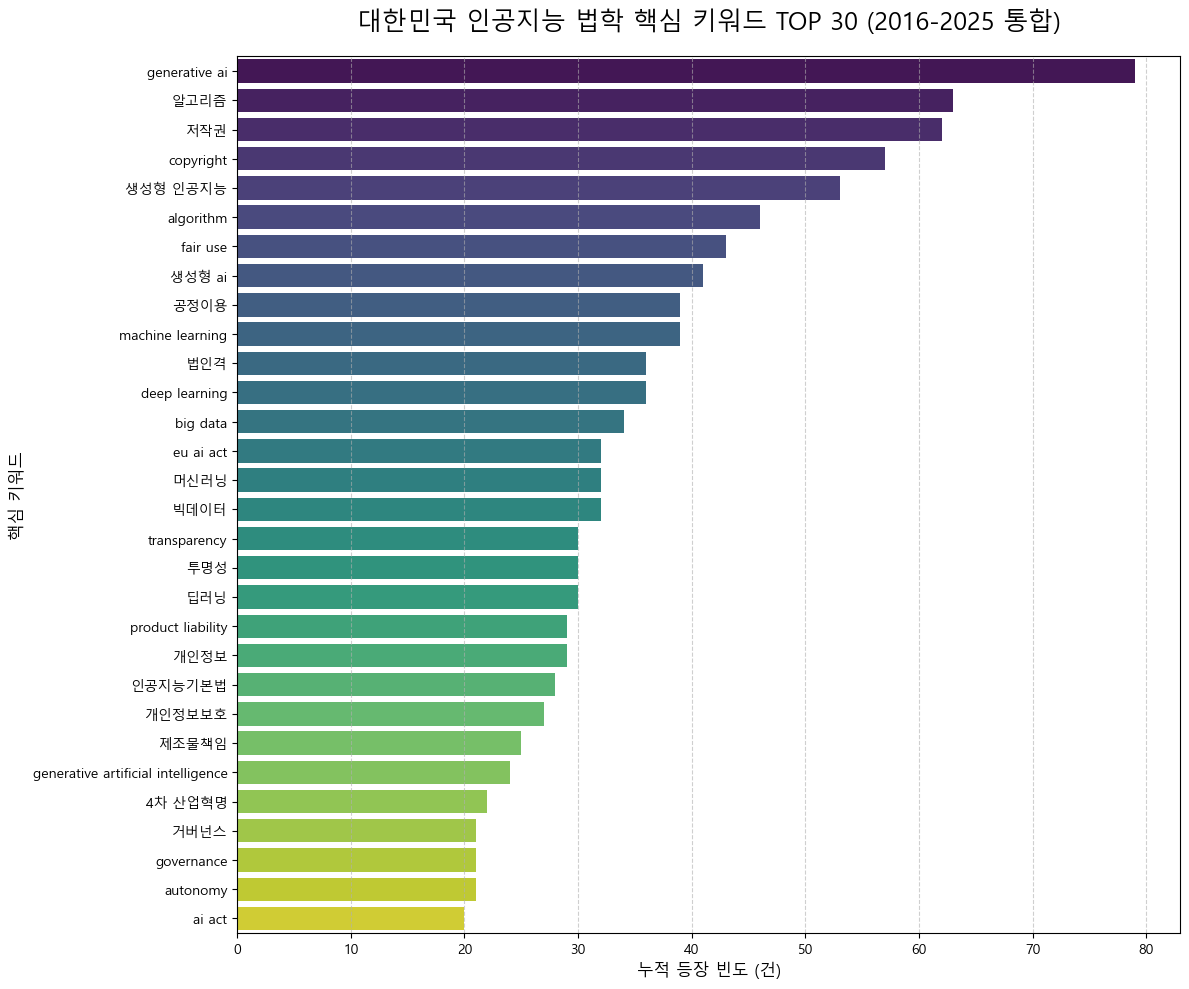

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

def analyze_total_aggregated_keywords(file_path):
    # 1. 데이터 로드 및 전처리
    df = pd.read_csv(file_path)
    df = df[df['발행연도'] >= 2016]
    
    # 논문 ID 기준 중복 제거 (필수)
    unique_papers = df.drop_duplicates(subset=['논문ID']).copy()
    
    def clean_kw(kw_str):
        if pd.isna(kw_str): return []
        words = str(kw_str).replace(']]>', '').split(',')
        # 소문자 통합 및 공백 제거
        cleaned = [w.strip().lower() for w in words if w.strip()]
        # 불용어 리스트 강화 (법학 논문 일반 용어 제거)
        stopwords = ['인공지능', 'ai', 'artificial intelligence', 'artificial intelligence(ai)', '인공지능(ai)', 'artificial intelligence (ai)']
        return [w for w in cleaned if w not in stopwords]

    unique_papers['cleaned_keywords'] = unique_papers['키워드'].apply(clean_kw)

    # 2. 전체 기간 키워드 통합 및 빈도 계산
    all_keywords = unique_papers['cleaned_keywords'].sum()
    # 상위 30개 추출
    total_top_30 = Counter(all_keywords).most_common(30)

    # 3. CSV 파일 저장
    result_df = pd.DataFrame(total_top_30, columns=['키워드', '누적빈도'])
    result_df.to_csv('AI_법학_전체기간_누적_핵심키워드.csv', index=False, encoding='utf-8-sig')
    print(f"✅ 분석 완료! 'AI_법학_전체기간_누적_핵심키워드.csv'가 저장되었습니다.")

    # 4. 시각화 (상위 30개 가로 바 차트)
    plt.figure(figsize=(12, 10))
    sns.barplot(x='누적빈도', y='키워드', data=result_df, palette='viridis')
    
    plt.title('대한민국 인공지능 법학 핵심 키워드 TOP 30 (2016-2025 통합)', fontsize=18, pad=20)
    plt.xlabel('누적 등장 빈도 (건)', fontsize=12)
    plt.ylabel('핵심 키워드', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.savefig('전체기간_누적_키워드_분석_30.png', dpi=300)
    plt.show()

# 실행
analyze_total_aggregated_keywords('KCI_AI_논문_상세_및_인용데이터.csv')

### 연도별 누적 키워드 분석

✅ 분석 완료! '연도별_전체_핵심키워드_변천사.csv'가 저장되었습니다.


C:\Users\silve\AppData\Local\Temp\ipykernel_44948\119216440.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='빈도', y='키워드', data=year_data, ax=axes[i], palette='viridis')
C:\Users\silve\AppData\Local\Temp\ipykernel_44948\119216440.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='빈도', y='키워드', data=year_data, ax=axes[i], palette='viridis')
C:\Users\silve\AppData\Local\Temp\ipykernel_44948\119216440.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='빈도', y='키워드', data=year_data, ax=axes[i], palette='viridis')
C:\Users\silve\A

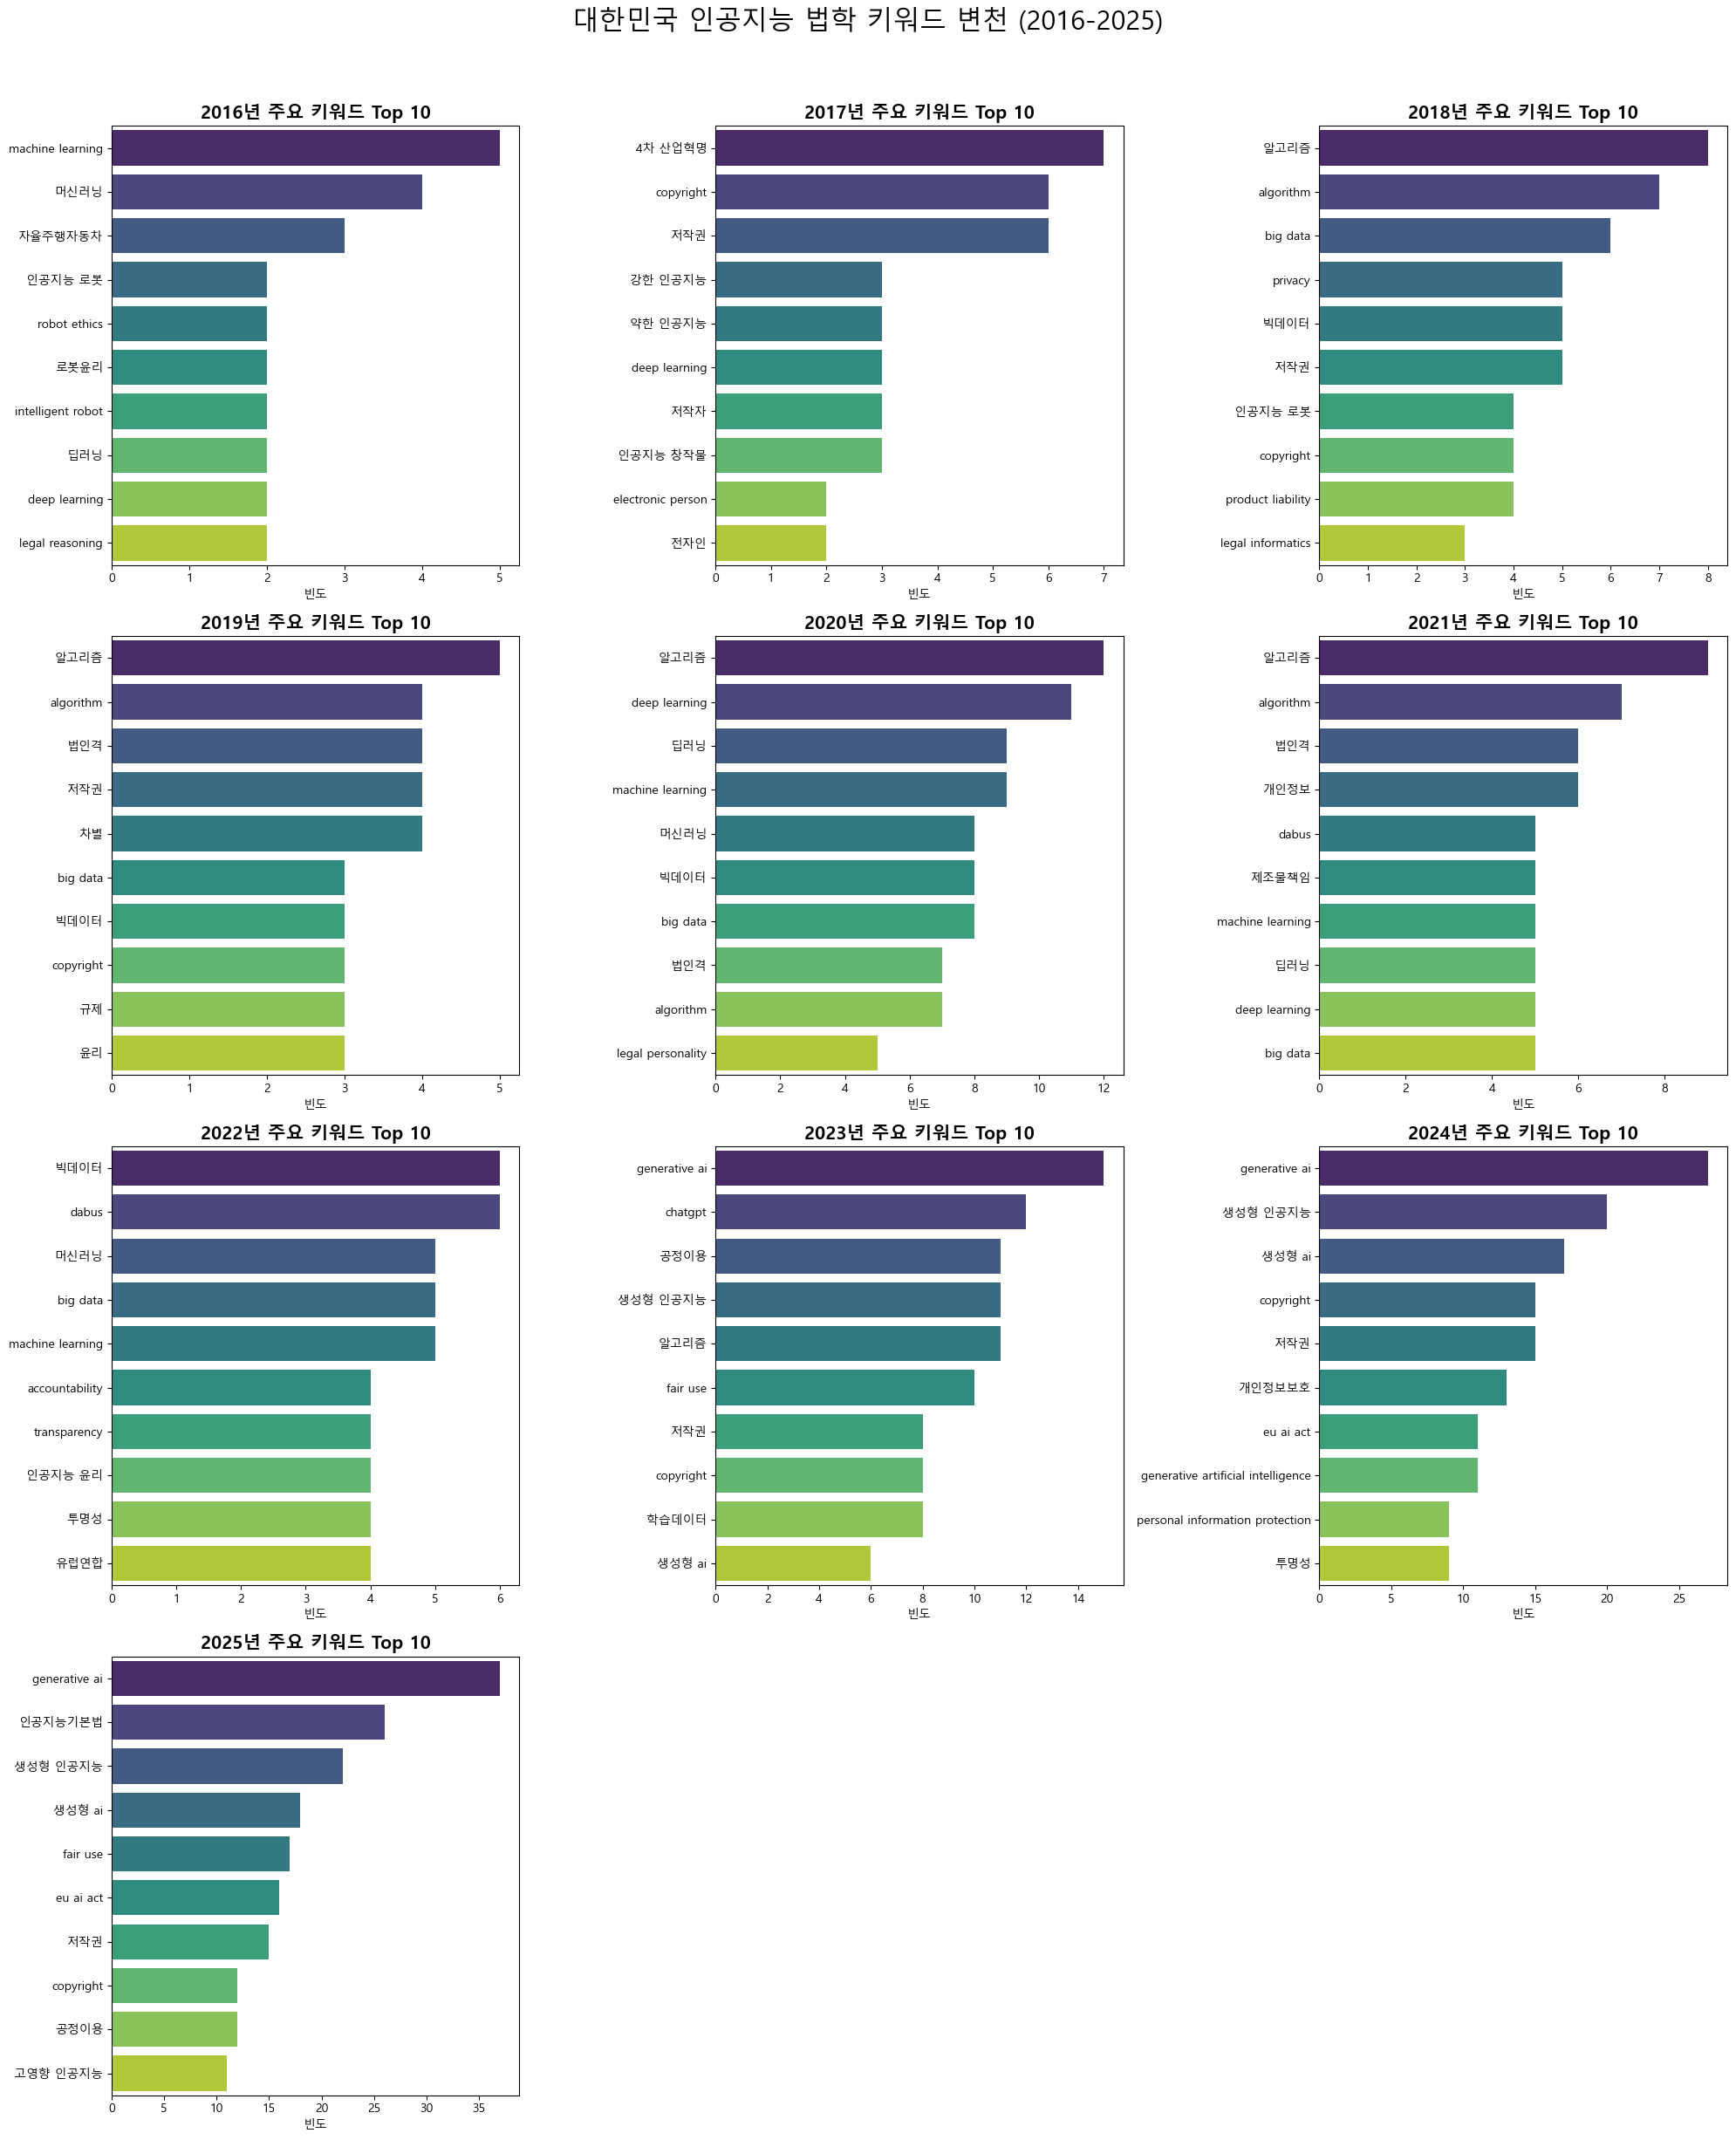

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import math

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

def analyze_yearly_keyword_transition(file_path):
    # 1. 데이터 로드 및 전처리
    df = pd.read_csv(file_path)
    df = df[df['발행연도'] >= 2016]
    
    # 논문 ID 기준 중복 제거 (데이터 신뢰도 확보)
    unique_papers = df.drop_duplicates(subset=['논문ID']).copy()
    
    def clean_kw(kw_str):
        if pd.isna(kw_str): return []
        # ']]>' 제거 및 쉼표 분리
        words = str(kw_str).replace(']]>', '').split(',')
        # 소문자 통합 및 공백 제거
        cleaned = [w.strip().lower() for w in words if w.strip()]
        # 법학 논문 특유의 일반 단어 및 불용어 제외
        stopwords = ['인공지능', 'ai', 'artificial intelligence', 'artificial intelligence(ai)', '인공지능(ai)', 'artificial intelligence (ai)']
        return [w for w in cleaned if w not in stopwords]

    unique_papers['cleaned_keywords'] = unique_papers['키워드'].apply(clean_kw)

    # 2. 연도별 Top 10 추출 및 CSV용 데이터 구성
    years = sorted(unique_papers['발행연도'].unique())
    num_years = len(years)
    
    yearly_results = []
    
    for year in years:
        # 해당 연도의 모든 논문 키워드 통합 (분류 무시)
        year_kws = unique_papers[unique_papers['발행연도'] == year]['cleaned_keywords'].sum()
        top_10 = Counter(year_kws).most_common(10)
        
        for rank, (word, freq) in enumerate(top_10, 1):
            yearly_results.append({
                '연도': int(year),
                '순위': rank,
                '키워드': word,
                '빈도': freq
            })

    # CSV 파일 저장
    result_df = pd.DataFrame(yearly_results)
    result_df.to_csv('연도별_전체_핵심키워드_변천사.csv', index=False, encoding='utf-8-sig')
    print(f"✅ 분석 완료! '연도별_전체_핵심키워드_변천사.csv'가 저장되었습니다.")

    # 3. 시각화 (연도별 Top 10 바 차트 그리드)
    cols = 3
    rows = math.ceil(num_years / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 6))
    axes = axes.flatten()

    for i, year in enumerate(years):
        year_data = result_df[result_df['연도'] == year]
        
        if not year_data.empty:
            sns.barplot(x='빈도', y='키워드', data=year_data, ax=axes[i], palette='viridis')
            axes[i].set_title(f'{year}년 주요 키워드 Top 10', fontsize=15, fontweight='bold')
            axes[i].set_xlabel('빈도')
            axes[i].set_ylabel('')

    # 빈 칸 제거
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle('대한민국 인공지능 법학 키워드 변천 (2016-2025)', fontsize=22, y=1.02)
    plt.tight_layout()
    plt.savefig('연도별_전체_키워드_변천사.png', dpi=300, bbox_inches='tight')
    plt.show()

# 실행
analyze_yearly_keyword_transition('KCI_AI_논문_상세_및_인용데이터.csv')

### TTR과 신규키워드 계산

In [ ]:
import pandas as pd
import os

def analyze_and_save_keyword_metrics(input_file, output_file='AI_법학_키워드_동태지표.csv'):
    # 1. 데이터 로드
    df = pd.read_csv(input_file)
    df = df[df['발행연도'] >= 2016]
    
    # [핵심] source_id 기반 중복 제거
    unique_papers = df.drop_duplicates(subset=['논문ID']).copy()
    
    print(f"📊 중복 제거 전 데이터: {len(df)}건")
    print(f"✅ 중복 제거 후 고유 논문: {len(unique_papers)}건")

    # 2. 키워드 세척 함수 (소문자 통합 로직 추가)
    def clean_kw(kw_str):
        if pd.isna(kw_str): return []
        
        # ']]>' 제거 및 쉼표 분리
        raw_words = str(kw_str).replace(']]>', '').split(',')
        
        # [수정] 앞뒤 공백 제거 및 모두 소문자로 변환 (Case Normalization)
        cleaned = [w.strip().lower() for w in raw_words if w.strip()]
        
        # [수정] 불용어 리스트도 소문자로 구성하여 정확히 매칭되도록 함
        stopwords = ['인공지능', 'ai', 'artificial intelligence', 'artificial intelligence(ai)', '인공지능(ai)', 'artificial intelligence (ai)']
        
        return [w for w in cleaned if w not in stopwords]

    unique_papers['cleaned_keywords'] = unique_papers['키워드'].apply(clean_kw)

    # 3. 연도별 지표 계산
    years = sorted(unique_papers['발행연도'].unique())
    seen_keywords = set() # 누적 지식 저장소
    metrics_list = []

    for year in years:
        year_rows = unique_papers[unique_papers['발행연도'] == year]
        year_kws_all = year_rows['cleaned_keywords'].sum()
        
        # --- 지표 산출 ---
        tokens = len(year_kws_all)  # 전체 키워드 빈도 (소문자 통합 상태)
        types = len(set(year_kws_all))  # 고유 키워드 개수 (소문자 통합 상태)
        
        # TTR(Type-Token Ratio) 계산
        ttr = types / tokens if tokens > 0 else 0
        
        # 신규 키워드 산출 (과거에 등장하지 않았던 소문자 키워드 집합)
        current_year_unique = set(year_kws_all)
        new_kws = current_year_unique - seen_keywords
        new_kw_count = len(new_kws)
        
        # 결과 기록
        metrics_list.append({
            '연도': int(year),
            '고유논문수': len(year_rows),
            '전체키워드빈도(Tokens)': tokens,
            '고유키워드개수(Types)': types,
            '어휘다양성(TTR)': round(ttr, 4),
            '신규키워드수': new_kw_count
        })
        
        # 누적 저장소 업데이트
        seen_keywords.update(current_year_unique)

    # 4. CSV 저장
    metrics_df = pd.DataFrame(metrics_list)
    metrics_df.to_csv(output_file, index=False, encoding='utf-8-sig')
    
    print("-" * 50)
    print(f"🏁 분석 완료! 결과가 '{output_file}'에 저장되었습니다.")
    print(metrics_df.to_string(index=False))
    
    return metrics_df

# 실행
final_stats = analyze_and_save_keyword_metrics('KCI_AI_논문_상세_및_인용데이터.csv')

📊 중복 제거 전 데이터: 31264건
✅ 중복 제거 후 고유 논문: 1072건
--------------------------------------------------
🏁 분석 완료! 결과가 'AI_법학_키워드_동태지표.csv'에 저장되었습니다.
  연도  고유논문수  전체키워드빈도(Tokens)  고유키워드개수(Types)  어휘다양성(TTR)  신규키워드수
2016     23              223             203      0.9103     203
2017     39              442             389      0.8801     353
2018     55              582             466      0.8007     370
2019     53              539             464      0.8609     365
2020     96             1112             888      0.7986     712
2021    106             1139             955      0.8385     705
2022     91              986             829      0.8408     606
2023    144             1529            1203      0.7868     917
2024    204             2157            1634      0.7575    1189
2025    261             2791            2128      0.7625    1563


### TTR과 신규키워드 수 플롯

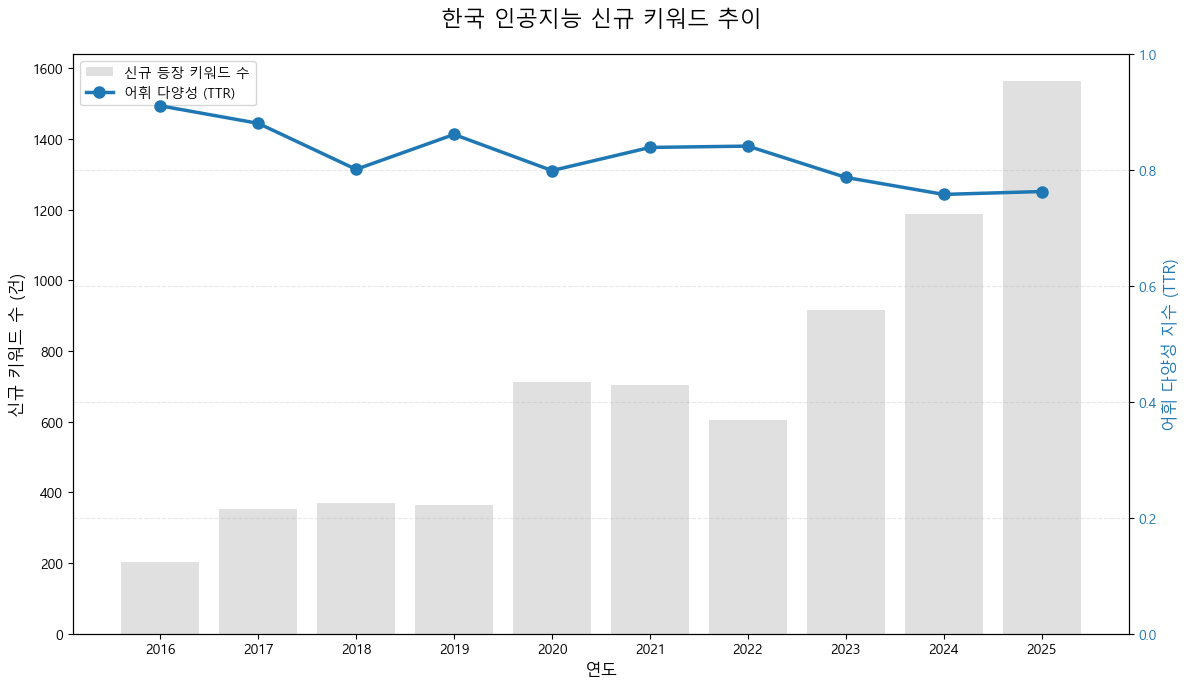

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set font for Korean display
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

def plot_dual_axis_metrics(csv_file):
    df = pd.read_csv(csv_file)
    
    fig, ax1 = plt.subplots(figsize=(12, 7))

    # Bar chart for New Keywords (Left Y-axis)
    color_bar = '#D3D3D3'  # Light Gray
    bars = ax1.bar(df['연도'], df['신규키워드수'], color=color_bar, alpha=0.7, label='신규 등장 키워드 수')
    ax1.set_xlabel('연도', fontsize=12)
    ax1.set_ylabel('신규 키워드 수 (건)', fontsize=12)
    ax1.set_xticks(df['연도'])

    # Line chart for TTR (Right Y-axis)
    ax2 = ax1.twinx()
    color_line = '#1F77B4'  # Professional Blue
    line = ax2.plot(df['연도'], df['어휘다양성(TTR)'], color=color_line, marker='o', linewidth=2.5, markersize=8, label='어휘 다양성 (TTR)')
    ax2.set_ylabel('어휘 다양성 지수 (TTR)', fontsize=12, color=color_line)
    ax2.tick_params(axis='y', labelcolor=color_line)
    ax2.set_ylim(0, 1.0) # TTR is a ratio between 0 and 1

    # Adding legends
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc='upper left', frameon=True)

    plt.title('한국 인공지능 신규 키워드 추이', fontsize=16, pad=20)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('AI_법학_동태지표_혼합그래프.png', dpi=300)
    plt.show() # Not showing, just saving as per instructions

plot_dual_axis_metrics('AI_법학_키워드_동태지표.csv')

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 한글 폰트 설정 (Windows 기준)
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

def analyze_growth_and_ratio(ai_file, total_file):
    # 1. 데이터 로드
    df_ai = pd.read_csv(ai_file)
    df_total = pd.read_csv(total_file)
    
    # 2. 연도별 집계 (2016-2025 범위 한정)
    # AI 논문 수 계산
    ai_counts = df_ai.groupby('발행연도').size().rename('AI_논문수')
    
    # 전체 법학 논문 수 계산 ('발행연도' 컬럼 기준)
    total_counts = df_total.groupby('발행연도').size().rename('전체_법학_논문수')
    
    # 두 데이터 합치기
    stats = pd.concat([total_counts, ai_counts], axis=1).fillna(0)
    stats = stats.loc[2016:2025] # 분석 기간 설정
    
    # 3. 지표 계산
    # (1) 전체 대비 비중 (%)
    stats['AI_비중(%)'] = (stats['AI_논문수'] / stats['전체_법학_논문수']) * 100
    
    # (2) 연평균 성장률(CAGR) 계산
    # 공식: (끝값 / 시작값) ^ (1 / 기간) - 1
    begin_val = stats['AI_논문수'].iloc[0]
    end_val = stats['AI_논문수'].iloc[-1]
    n_years = len(stats) - 1
    cagr = (end_val / begin_val)**(1 / n_years) - 1
    
    print(f"📈 2015-2024 AI 법학 연평균 성장률(CAGR): {cagr:.2%}")
    print(stats[['전체_법학_논문수', 'AI_논문수', 'AI_비중(%)']])

    # 4. 시각화 (이중 축 그래프)
    fig, ax1 = plt.subplots(figsize=(12, 7))
    
    # 축 1: AI 논문 수 (막대 그래프)
    sns.barplot(x=stats.index, y=stats['AI_논문수'], ax=ax1, color='skyblue', alpha=0.7, label='AI 논문 수')
    ax1.set_ylabel('AI 법학 논문 수 (건)', fontsize=12)
    ax1.set_xlabel('연도', fontsize=12)
    
    # 축 2: 비중 (꺾은선 그래프)
    ax2 = ax1.twinx()
    sns.lineplot(x=np.arange(len(stats)), y=stats['AI_비중(%)'], ax=ax2, color='red', marker='o', linewidth=2, label='전체 법학 대비 비중 (%)')
    ax2.set_ylabel('전체 법학 대비 비중 (%)', fontsize=12, color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    # 타이틀 및 범례
    plt.title(f'연도별 인공지능 법학 논문 출간 수 및 전체 법학 논문 대비 비율 ', fontsize=16, pad=20)
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.savefig('AI법학_성장성_및_비중분석.png', dpi=300)
    plt.show()

analyze_growth_and_ratio('AI_논문_분야별_분류_최종.csv', '전체_법학_논문목록_정제본.csv')

KeyError: '발행연도'